[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NeuromatchAcademy/course-content-dl/blob/main/projects/Neuroscience/pose_estimation.ipynb)
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/projects/Neuroscience/pose_estimation.ipynb)

# Animal Pose Estimation
**By Neuromatch Academy**

__Content creators:__ Kristin Branson

__Produtction editors:__ Gagana B, Spiros Chavlis

---
# Objectives

Train a deep network that can predict the locations of parts of animals. This Colab Notebook has all the code necessary to train a UNet network to predict the positions of 17 parts on a fruit fly.

**Project ideas:**

1. (easy-medium) Improve the pose estimator. Some possible ideas to explore:
  * (easy) Data augmentation: It is common to train a network to be robust to certain kinds of perturbations by adding random perturbations to the training data. Try modifying the COCODataset to perform data augmentation. The mmpose toolkit has some data transforms relevant for pose tracking here
[https://github.com/open-mmlab/mmpose/blob/b0acfc423da672e61db75e00df9da106b6ead574/mmpose/datasets/pipelines/top_down_transform.py](https://github.com/open-mmlab/mmpose/blob/b0acfc423da672e61db75e00df9da106b6ead574/mmpose/datasets/pipelines/top_down_transform.py)
  * (medium) Network architecture: There are tons of networks people have designed for pose estimation. The mmpose toolbox has many networks implemented:
[https://github.com/open-mmlab/mmpose](https://github.com/open-mmlab/mmpose). Can you improve the accuracy with more exotic networks than the UNet? To do this, you should define a new network class, similar to the definition of [UNet](https://colab.research.google.com/drive/1SLgOHcgo1bfMDx5wlnLqm05AZe6aVG0l?authuser=1#scrollTo=Yf4vdxN7v9Rz&line=5&uniqifier=1). If you need a different loss function, you will also need to change the criterion used for training.
  * (easy to medium) Optimization algorithm: Feed-forward convolutional networks have been engineered (e.g. by adding batch normalization layers) to be pretty robust to the exact choice of gradient descent algorithm, but there is still room for improvement in this code.
  * Other ideas? Look at the errors the network is making -- how might we improve the tracker?
  * (medium) Our training data set was relatively large -- 4216 examples. Can we get away with less examples than this? Can we change our algorithm to work better with smaller data sets? One idea to look into is pre-training the network on a different data set.
  * Note: The data provided consists of both a training and a test set. It is important to not overfit to the test set, and only use it for a final evaluation. This code splits the training set into a training and a validation data set. Use this split data for testing out different algorithms. Then, after you finish developing your algorithm you can evaluate it on the test data.
2. (easy) Train a pose estimator for a different data set.
  * This Notebook has code for training a fly part tracker. More animal pose data sets can be found here: [https://mmpose.readthedocs.io/en/latest/tasks/2d_animal_keypoint.html](https://mmpose.readthedocs.io/en/0.x/tasks/2d_animal_keypoint.html)
  * You can label your own dataset using animal tracking software like
  DeepLabCut [http://www.mackenziemathislab.org/deeplabcut](http://www.mackenziemathislab.org/deeplabcut)
  or APT [http://kristinbranson.github.io/APT/](http://kristinbranson.github.io/APT/)
  * To use a different data set, you might need to make a new Dataset class similar to our COCODataset class.
3. (medium) Explore how well the network generalizes to data collected in other labs. Can you train a pose estimator that works on lots of different types of data?
3. (easy) Explore using tensorboard with this network. Tensorboard lets you monitor and visualize training, and is an important tool as you develop and debug algorithms. A tutorial on using Tensorboard is here
[https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html](https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html)
A Colab Notebook using tensorboard is here:
[https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/tensorboard_with_pytorch.ipynb](https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/tensorboard_with_pytorch.ipynb)
4. (hard) Explore how the network is making its decisions using explainable AI techniques.

Acknowledgments:
This Notebook was developed by Kristin Branson. It borrows from:
* APT [https://github.com/kristinbranson/APT](https://github.com/kristinbranson/APT)
* Milesi Alexandre's UNet implementation [https://github.com/milesial/Pytorch-UNet](https://github.com/milesial/Pytorch-UNet)

---
# Setup

In [23]:
# @title Install dependencies
!pip install opencv-python --quiet
!pip install google.colab --quiet

In [24]:
# Imports
import re
import os
import cv2
import json
import torch
import torchvision

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch.nn as nn
from torch import optim
import torch.nn.functional as F

from tqdm import tqdm
from glob import glob

In [25]:
# @title Helper function
def PlotLabelAndPrediction(batch, hm_pred, idx=None, title_string=''):
  """
  PlotLabelAndPrediction(batch,pred,idx=None):
  Plot the input, labels, and predictions for a batch.
  """
  isbatch = isinstance(batch['id'], torch.Tensor)

  if idx is None and isbatch:
    idx = range(len(batch['id']))
  if isbatch:
    n = len(idx)
  else:
    n = 1
    idx = [None,]
  locs_pred = heatmap2landmarks(hm_pred.cpu().numpy())
  for i in range(n):

    plt.subplot(n, 4, 4*i + 1)
    im = COCODataset.get_image(batch, idx[i])
    plt.imshow(im,cmap='gray')
    locs = COCODataset.get_landmarks(batch, idx[i])
    for k in range(train_dataset.nlandmarks):
      plt.plot(locs[k, 0], locs[k, 1],
               marker='.', color=colors[k],
               markerfacecolor=colors[k])
    if isbatch:
      batchid = batch['id'][i]
    else:
      batchid = batch['id']
    plt.title(f"{title_string}{batchid}")

    plt.subplot(n, 4, 4*i + 2)
    plt.imshow(im,cmap='gray')
    locs = COCODataset.get_landmarks(batch, idx[i])
    if isbatch:
      locs_pred_curr = locs_pred[i, ...]
    else:
      locs_pred_curr = locs_pred
    for k in range(train_dataset.nlandmarks):
      plt.plot(locs_pred_curr[k, 0], locs_pred_curr[k, 1],
               marker='.', color=colors[k],
               markerfacecolor=colors[k])
    if i == 0: plt.title('pred')

    plt.subplot(n, 4, 4*i + 3)
    hmim = COCODataset.get_heatmap_image(batch, idx[i])
    plt.imshow(hmim)
    if i == 0: plt.title('label')

    plt.subplot(n, 4, 4*i + 4)
    if isbatch:
      predcurr = hm_pred[idx[i], ...]
    else:
      predcurr = hm_pred
    plt.imshow(heatmap2image(predcurr.cpu().numpy(), colors=colors))
    if i == 0: plt.title('pred')

In [26]:
print(f"numpy version: {np.__version__}")
print(f"\nCUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\ntorch version: {torch.__version__}")

numpy version: 2.0.2

CUDA available: True

torch version: 2.11.0+cu128


In [27]:
# @title Download the data
import os, requests, tarfile

fname = 'fly_bubble_20201204.tar.gz'
url = 'https://osf.io/q7vhy/download'
datadir = 'view0'

if not os.path.exists(fname):
  r = requests.get(url, allow_redirects=True)
  with open(fname, 'wb') as ftar:
    ftar.write(r.content)
  print('Fly pose data have been downloaded.')

# Untar fly pose data
if not os.path.exists(datadir):
  with tarfile.open(fname, 'r') as f:
    f.extractall('.')  # specify which folder to extract to
    # remove tar file
    os.remove(fname)
    print('Fly pose data have been unzipped.')
else:
  print('Fly pose data already unzipped.')

Fly pose data have been downloaded.
Fly pose data already unzipped.


---
# Mount your gDrive

Get the pose data set. To do this, you need to make a shortcut to a shared Google Drive directory in your Google Drive.

1.   Go to the shared Google Drive: [https://drive.google.com/drive/folders/1a06ZAmQXvUqZZQGI9XWWjABl4vOF8v6Z?usp=sharing](https://drive.google.com/drive/folders/1a06ZAmQXvUqZZQGI9XWWjABl4vOF8v6Z?usp=sharing)
2.   Select "Add shortcut to Drive" and select "My Drive".

<img src="https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/projects/static/Screenshot_AddShortcutToPoseData.png">



In [28]:
gDrive = False

In [29]:
# @markdown set the `gDrive=True` and run the cell.
from google.colab import drive

if gDrive:
  print('The first time you run this, it will ask you to verify that Google Colab can access your Google Drive.')
  print('Follow the instructions -- go to the linked website, and copy-paste the provided code.')
  drive.flush_and_unmount()
  drive.mount('/content/drive', force_remount=True)
  assert os.path.exists('/content/drive/My Drive'), 'Google drive not mounted'

  # Unzip fly pose data
  datadir = 'view0'
  if not os.path.exists(datadir):
    assert os.path.exists('/content/drive/My Drive/fly_bubble_pose/fly_bubble_20201204.tar.gz'), 'Fly pose data zip file not found'
    !tar -xvzf '/content/drive/My Drive/fly_bubble_pose/fly_bubble_20201204.tar.gz' > /dev/null
    assert os.path.exists(datadir), 'view0 not created after unzipping data'
  else:
    print('Fly pose data already unzipped')

In [30]:
# Make sure all the data exists
traindir = os.path.join(datadir, 'train')
trainannfile = os.path.join(datadir, 'train_annotations.json')
testdir = os.path.join(datadir, 'test')
testannfile = os.path.join(datadir, 'test_annotations.json')
assert os.path.exists(traindir) and os.path.exists(testdir) and os.path.exists(trainannfile) and os.path.exists(testannfile), 'Could not find all necessary data after unzipping'
print('Found all the fly pose data')

# Read annotation information
with open(trainannfile) as f:
  trainann = json.load(f)
f.close()
ntrainims = len(trainann['images'])
# Make sure we have all the images
t = glob(os.path.join(traindir,'*.png'))
print(f"N. train images = {ntrainims}, number of images unzipped = {len(t)}")
assert ntrainims == len(t), 'number of annotations and number of images do not match'

# get some features of the data set
i = 0
filestr = trainann['images'][0]['file_name']
imfile = os.path.join(traindir,filestr)
im = cv2.imread(imfile, cv2.IMREAD_UNCHANGED)
imsize = im.shape
if len(imsize) == 2:
  imsize += (1, )
print(f"input image size: {imsize}")

landmark_names = ['head_fc', 'head_bl', 'head_br', 'thorax_fr', 'thorax_fl',
                  'thorax_bc', 'abdomen', 'leg_ml_in', 'leg_ml_c',' leg_mr_in',
                  'leg_mr_c', 'leg_fl_tip', 'leg_ml_tip', 'leg_bl_tip',
                  'leg_br_tip','leg_mr_tip','leg_fr_tip']
nlandmarks = trainann['annotations'][0]['num_keypoints']
assert nlandmarks == len(landmark_names)

Found all the fly pose data
N. train images = 4216, number of images unzipped = 4216
input image size: (181, 181, 1)


---
# Visulaize the data

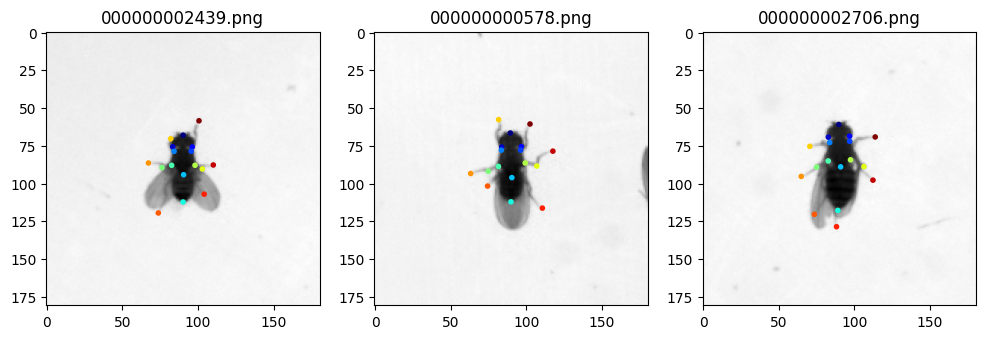

In [31]:
# Show some example images
nimsshow = 3  # number of images to plot
imsshow = np.random.choice(ntrainims,nimsshow)
fig = plt.figure(figsize=(4*nimsshow, 4), dpi=100)  # make the figure bigger
for i in range(nimsshow):
  filestr = trainann['images'][imsshow[i]]['file_name']
  imfile = os.path.join(traindir, filestr)
  im = cv2.imread(imfile, cv2.IMREAD_UNCHANGED)
  plt.subplot(1,nimsshow,i+1)
  plt.imshow(im,cmap='gray')
  x = trainann['annotations'][imsshow[i]]['keypoints'][::3]
  y = trainann['annotations'][imsshow[i]]['keypoints'][1::3]
  plt.scatter(x, y, marker='.', c=np.arange(nlandmarks), cmap='jet')
  plt.title(filestr)
plt.show()

In [32]:
# define a dataset class to load the data

def heatmap2image(hm, cmap='jet', colors=None):
  """
  heatmap2image(hm,cmap='jet',colors=None)
  Creates and returns an image visualization from landmark heatmaps. Each
  landmark is colored according to the input cmap/colors.
  Inputs:
    hm: nlandmarks x height x width ndarray, dtype=float in the range 0 to 1.
    hm[p,i,j] is a score indicating how likely it is that the pth landmark
    is at pixel location (i,j).
    cmap: string.
    Name of colormap for defining colors of landmark points. Used only if colors
    is None.
    Default: 'jet'
    colors: list of length nlandmarks.
    colors[p] is an ndarray of size (4,) indicating the color to use for the
    pth landmark. colors is the output of matplotlib's colormap functions.
    Default: None
  Output:
    im: height x width x 3 ndarray
    Image representation of the input heatmap landmarks.
  """
  hm = np.maximum(0., np.minimum(1. ,hm))
  im = np.zeros((hm.shape[1], hm.shape[2], 3))
  if colors is None:
    if isinstance(cmap, str):
      cmap = matplotlib.cm.get_cmap(cmap)
    colornorm = matplotlib.colors.Normalize(vmin=0, vmax=hm.shape[0])
    colors = cmap(colornorm(np.arange(hm.shape[0])))
  for i in range(hm.shape[0]):
    color = colors[i]
    for c in range(N_RUNS):
      im[..., c] = im[..., c] + (color[c] * .7 + .3) * hm[i, ...]
  im = np.minimum(1.,im)

  return im


class COCODataset(torch.utils.data.Dataset):
  """
  COCODataset
  Torch Dataset based on the COCO keypoint file format.
  """

  def __init__(self, annfile, datadir=None, label_sigma=3.,
               transform=None, landmarks=None):
    """
    Constructor
    This must be defined in every Torch Dataset and can take any inputs you
    want it to.
    Inputs:
      annfile: string
      Path to json file containing annotations.
      datadir: string
      Path to directory containing images. If None, images are assumed to be in
      the working directory.
      Default: None
      label_sigma: scalar float
      Standard deviation in pixels of Gaussian to be used to make the landmark
      heatmap.
      Default: 3.
      transform: None
      Not used currently
      landmarks: ndarray (or list, something used for indexing into ndarray)
      Indices of landmarks available to use in this dataset. Reducing the
      landmarks used can make training faster and require less memory, and is
      useful for testing code. If None, all landmarks are used.
      Default: None
    """

    # read in the annotations from the json file
    with open(annfile) as f:
      self.ann = json.load(f)
    # where the images are
    self.datadir = datadir

    # landmarks to use
    self.nlandmarks_all = self.ann['annotations'][0]['num_keypoints']
    if landmarks is None:
      self.nlandmarks = self.nlandmarks_all
    else:
      self.nlandmarks = len(landmarks)
    self.landmarks = landmarks

    # for data augmentation/rescaling
    self.transform = transform

    # output will be heatmap images, one per landmark, with Gaussian values
    # around the landmark location -- precompute some stuff for that
    self.label_filter = None
    self.label_filter_r = 1
    self.label_filter_d = 3
    self.label_sigma = label_sigma
    self.init_label_filter()

  def __len__(self):
    """
    Overloaded len function.
    This must be defined in every Torch Dataset and must take only self
    as input.
    Returns the number of examples in the dataset.
    """
    return len(self.ann['images'])

  def __getitem__(self, item):
    """
    Overloaded getitem function.
    This must be defined in every Torch Dataset and must take only self
    and item as input. It returns example number item.
    item: scalar integer.
    The output example is a dict with the following fields:
    image: torch float32 tensor of size ncolors x height x width
    landmarks: nlandmarks x 2 float ndarray
    heatmaps: torch float32 tensor of size nlandmarks x height x width
    id: scalar integer, contains item
    """

    # read in the image for training example item
    # and convert to a torch tensor
    filename = self.ann['images'][item]['file_name']
    if self.datadir is not None:
      filename = os.path.join(self.datadir, filename)
    assert os.path.exists(filename)
    im = torch.from_numpy(cv2.imread(filename, cv2.IMREAD_UNCHANGED))

    # convert to float32 in the range 0. to 1.
    if im.dtype == float:
      pass
    elif im.dtype == torch.uint8:
      im = im.float() / 255.
    elif im.dtype == torch.uint16:
      im = im.float() / 65535.
    else:
      print('Cannot handle im type '+str(im.dtype))
      raise TypeError

    imsz = im.shape
    # convert to a tensor of size ncolors x h x w
    if im.dim() == 3:
      im = torch.transpose(im, [2, 0, 1])  # now 3 x h x w
    else:
      im = torch.unsqueeze(im, 0)  # now 1 x h x w

    # landmark locations
    locs = np.reshape(self.ann['annotations'][item]['keypoints'],
                      [self.nlandmarks_all, 3])
    locs = locs[:, :2]
    if self.landmarks is not None:
      locs = locs[self.landmarks, :]

    # create heatmap target prediction
    heatmaps = self.make_heatmap_target(locs, imsz)

    # return a dict with the following fields:
    # image: torch float32 tensor of size ncolors x height x width
    # landmarks: nlandmarks x 2 float ndarray
    # heatmaps: torch float32 tensor of size nlandmarks x height x width
    # id: scalar integer, contains item
    features = {'image':im,
                'landmarks':locs.astype(np.float32),
                'heatmaps':heatmaps,
                'id':item}

    return features

  def init_label_filter(self):
    """
    init_label_filter(self)
    Helper function
    Create a Gaussian filter for the heatmap target output
    """
    # radius of the filter
    self.label_filter_r = max(int(round(3 * self.label_sigma)), 1)
    # diameter of the filter
    self.label_filter_d = 2 * self.label_filter_r + 1

    # allocate
    self.label_filter = np.zeros([self.label_filter_d, self.label_filter_d])
    # set the middle pixel to 1.
    self.label_filter[self.label_filter_r, self.label_filter_r] = 1.
    # blur with a Gaussian
    self.label_filter = cv2.GaussianBlur(self.label_filter,
                                         (self.label_filter_d,
                                          self.label_filter_d),
                                         self.label_sigma)
    # normalize
    self.label_filter = self.label_filter / np.max(self.label_filter)
    # convert to torch tensor
    self.label_filter = torch.from_numpy(self.label_filter)

  def make_heatmap_target(self, locs, imsz):
    """
    make_heatmap_target(self,locs,imsz):
    Helper function
    Creates the heatmap tensor of size imsz corresponding to landmark locations locs
    Inputs:
      locs: nlandmarks x 2 ndarray
      Locations of landmarks
      imsz: image shape
    Returns:
      target: torch tensor of size nlandmarks x imsz[0] x imsz[1]
      Heatmaps corresponding to locs
    """
    # allocate the tensor
    target = torch.zeros((locs.shape[0], imsz[0], imsz[1]), dtype=torch.float32)
    # loop through landmarks
    for i in range(locs.shape[0]):
      # location of this landmark to the nearest pixel
      x = int(np.round(locs[i, 0])) # losing sub-pixel accuracy
      y = int(np.round(locs[i, 1]))
      # edges of the Gaussian filter to place, minding border of image
      x0 = np.maximum(0, x - self.label_filter_r)
      x1 = np.minimum(imsz[1] - 1, x + self.label_filter_r)
      y0 = np.maximum(0, y - self.label_filter_r)
      y1 = np.minimum(imsz[0] - 1, y + self.label_filter_r)
      # crop filter if it goes outside of the image
      fil_x0 = self.label_filter_r - (x - x0)
      fil_x1 = self.label_filter_d - (self.label_filter_r - (x1 - x))
      fil_y0 = self.label_filter_r - (y - y0)
      fil_y1 = self.label_filter_d - (self.label_filter_r - (y1 - y))
      # copy the filter to the relevant part of the heatmap image
      target[i, y0:y1 + 1, x0:x1 + 1] = self.label_filter[fil_y0:fil_y1 + 1,
                                                          fil_x0:fil_x1 + 1]

    return target

  @staticmethod
  def get_image(d, i=None):
    """
    static function, used for visualization
    COCODataset.get_image(d,i=None)
    Returns an image usable with plt.imshow()
    Inputs:
      d: if i is None, item from a COCODataset.
      if i is a scalar, batch of examples from a COCO Dataset returned
      by a DataLoader.
      i: Index of example into the batch d, or None if d is a single example
    Returns the ith image from the patch as an ndarray plottable with
    plt.imshow()
    """
    if i is None:
      im = np.squeeze(np.transpose(d['image'].numpy(), (1, 2, 0)), axis=2)
    else:
      im = np.squeeze(np.transpose(d['image'][i,...].numpy(), (1, 2, 0)), axis=2)
    return im

  @staticmethod
  def get_landmarks(d, i=None):
    """
    static helper function
    COCODataset.get_landmarks(d,i=None)
    Returns a nlandmarks x 2 ndarray indicating landmark locations.
    Inputs:
      d: if i is None, item from a COCODataset.
      if i is a scalar, batch of examples from a COCO Dataset returned
      by a DataLoader.
      i: Index of example into the batch d, or None if d is a single example
    """
    if i is None:
      locs = d['landmarks']
    else:
      locs = d['landmarks'][i]
    return locs

  @staticmethod
  def get_heatmap_image(d, i, cmap='jet', colors=None):
    """
    static function, used for visualization
    COCODataset.get_heatmap_image(d,i=None)
    Returns an image visualization of heatmaps usable with plt.imshow()
    Inputs:
      d: if i is None, item from a COCODataset.
      if i is a scalar, batch of examples from a COCO Dataset returned
      by a DataLoader.
      i: Index of example into the batch d, or None if d is a single example
      Returns the ith heatmap from the patch as an ndarray plottable with
      plt.imshow()
      cmap: string.
      Name of colormap for defining colors of landmark points. Used only if colors
      is None.
      Default: 'jet'
      colors: list of length nlandmarks.
      colors[p] is an ndarray of size (4,) indicating the color to use for the
      pth landmark. colors is the output of matplotlib's colormap functions.
      Default: None
    Output:
      im: height x width x 3 ndarray
      Image representation of the input heatmap landmarks.
    """
    if i is None:
      hm = d['heatmaps']
    else:
      hm = d['heatmaps'][i, ...]
    hm = hm.numpy()
    im = heatmap2image(hm, cmap=cmap, colors=colors)

    return im

/tmp/ipykernel_546/2476673002.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('jet')


{'image': tensor([[[[0.8588, 0.8549, 0.8588,  ..., 0.8157, 0.8196, 0.8196],
          [0.8549, 0.8588, 0.8667,  ..., 0.8157, 0.8196, 0.8235],
          [0.8588, 0.8627, 0.8627,  ..., 0.8157, 0.8196, 0.8235],
          ...,
          [0.8431, 0.8431, 0.8431,  ..., 0.8118, 0.8118, 0.8118],
          [0.8392, 0.8431, 0.8431,  ..., 0.8118, 0.8118, 0.8039],
          [0.8431, 0.8431, 0.8392,  ..., 0.8118, 0.8118, 0.8039]]],


        [[[0.8431, 0.8431, 0.8431,  ..., 0.8392, 0.8392, 0.8431],
          [0.8431, 0.8431, 0.8431,  ..., 0.8431, 0.8392, 0.8392],
          [0.8431, 0.8471, 0.8392,  ..., 0.8392, 0.8392, 0.8392],
          ...,
          [0.8588, 0.8588, 0.8627,  ..., 0.8706, 0.8706, 0.8706],
          [0.8588, 0.8549, 0.8588,  ..., 0.8706, 0.8706, 0.8667],
          [0.8627, 0.8549, 0.8549,  ..., 0.8706, 0.8667, 0.8706]]]]), 'landmarks': tensor([[[ 89.8087,  67.5499],
         [ 83.2190,  74.9118],
         [ 96.8632,  74.3610],
         [ 95.5130,  77.0612],
         [ 84.0369,  77

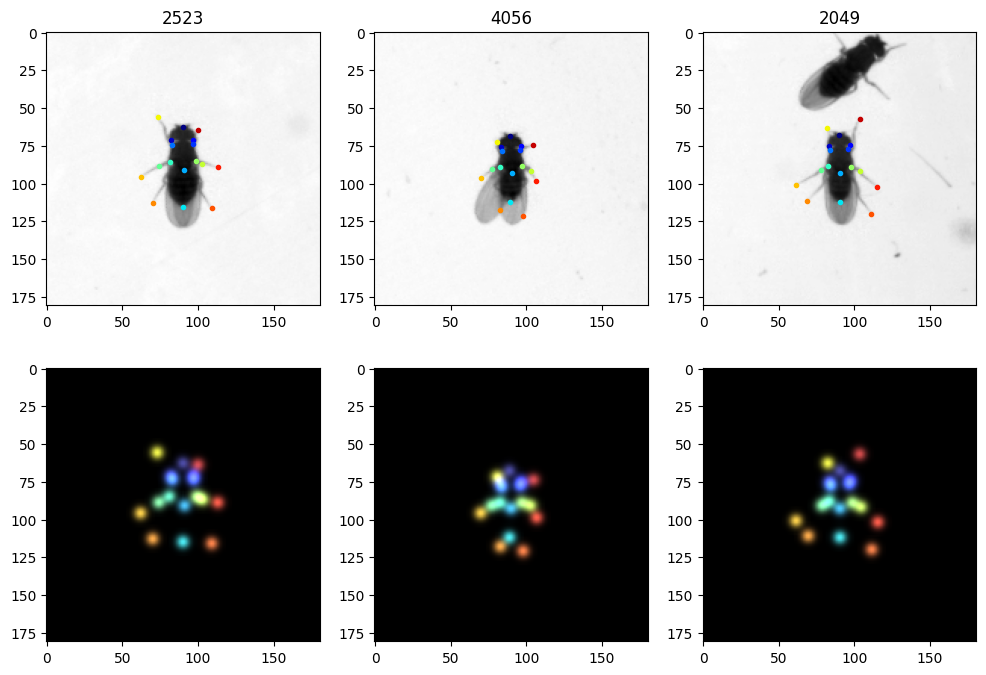

In [33]:
# instantiate train data loader

# only use a subset of the landmarks
#landmarks = np.where(list(map(lambda x: x in ['head_fc','leg_fl_tip','leg_fr_tip'],landmark_names)))[0]
# use all the landmarks
landmarks = None

train_dataset = COCODataset(trainannfile, datadir=traindir, landmarks=landmarks)
train_dataloader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size=2,
                                               shuffle=True)

# plot example images using the dataloader
fig = plt.figure(figsize=(nimsshow * 4, 8), dpi=100)

# choose some colors for each landmark
cmap = matplotlib.cm.get_cmap('jet')
colornorm = matplotlib.colors.Normalize(vmin=0, vmax=train_dataset.nlandmarks)
colors = cmap(colornorm(np.arange(train_dataset.nlandmarks)))

count = 0
for i_batch, sample_batch in enumerate(train_dataloader):
  for j in range(len(sample_batch['id'])):
    plt.subplot(2, nimsshow, count + 1)
    # use our helper functions for getting and formatting data from the batch
    im = COCODataset.get_image(sample_batch, j)
    locs = COCODataset.get_landmarks(sample_batch, j)
    plt.imshow(im, cmap='gray')
    for k in range(train_dataset.nlandmarks):
      plt.plot(locs[k, 0], locs[k, 1], marker='.', color=colors[k],
               markerfacecolor=colors[k])
    plt.title('%d'%sample_batch['id'][j])
    hmim = COCODataset.get_heatmap_image(sample_batch, j, colors=colors)
    plt.subplot(2, nimsshow, count + 1 + nimsshow)
    plt.imshow(hmim)
    count += 1
    if count >= nimsshow:
      break
  if count >= nimsshow:
    break

# Show the structure of a batch
print(sample_batch)

---
# Architectures

In [34]:
# Define network structure - UNet
# Copy-paste & modify from https://github.com/milesial/Pytorch-UNet

# The UNet is defined modularly.
# It is a series of downsampling layers defined by the module Down
# followed by upsampling layers defined by the module Up. The output is
# a convolutional layer with an output channel for each landmark, defined by
# the module OutConv.
# Each down and up layer is actually two convolutional layers with
# a ReLU nonlinearity and batch normalization, defined by the module
# DoubleConv.
# The Down module consists of a 2x2 max pool layer followed by the DoubleConv
# module.
# The Up module consists of an upsampling, either defined via bilinear
# interpolation (bilinear=True), or a learned convolutional transpose, followed
# by a DoubleConv module.
# The Output layer is a single 2-D convolutional layer with no nonlinearity.
# The nonlinearity is incorporated into the network loss function.

class DoubleConv(nn.Module):
  """(convolution => [BN] => ReLU) * 2"""

  def __init__(self, in_channels, out_channels, mid_channels=None):
    super().__init__()
    if not mid_channels:
        mid_channels = out_channels
    self.double_conv = nn.Sequential(
        nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(mid_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
        )

  def forward(self, x):
    return self.double_conv(x)


class Down(nn.Module):
  """Downscaling with maxpool then double conv"""

  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.maxpool_conv = nn.Sequential(
        nn.MaxPool2d(2),
        DoubleConv(in_channels, out_channels)
        )

  def forward(self, x):
    return self.maxpool_conv(x)


class Up(nn.Module):
  """Upscaling then double conv"""

  def __init__(self, in_channels, out_channels, bilinear=True):
    super().__init__()

    # if bilinear, use the normal convolutions to reduce the number of channels
    if bilinear:
      self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
      self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
    else:
      self.up = nn.ConvTranspose2d(in_channels , in_channels // 2, kernel_size=2, stride=2)
      self.conv = DoubleConv(in_channels, out_channels)


  def forward(self, x1, x2):
    x1 = self.up(x1)
    # input is CHW
    diffY = x2.size()[2] - x1.size()[2]
    diffX = x2.size()[3] - x1.size()[3]

    x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                    diffY // 2, diffY - diffY // 2])
    # if you have padding issues, see
    # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
    # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
    x = torch.cat([x2, x1], dim=1)
    return self.conv(x)


class OutConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(OutConv, self).__init__()
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

  def forward(self, x):
    return self.conv(x)

# copy-pasted and modified from unet_model.py

class UNet(nn.Module):
  def __init__(self, n_channels, n_landmarks, bilinear=True):
    super(UNet, self).__init__()
    self.n_channels = n_channels
    self.n_landmarks = n_landmarks
    self.bilinear = bilinear
    self.nchannels_inc = 8

    # define the layers

    # number of channels in the first layer
    nchannels_inc = self.nchannels_inc
    # increase the number of channels by a factor of 2 each layer
    nchannels_down1 = nchannels_inc*2
    nchannels_down2 = nchannels_down1*2
    nchannels_down3 = nchannels_down2*2
    # decrease the number of channels by a factor of 2 each layer
    nchannels_up1 = nchannels_down3//2
    nchannels_up2 = nchannels_up1//2
    nchannels_up3 = nchannels_up2//2

    if bilinear:
      factor = 2
    else:
      factor = 1

    self.layer_inc = DoubleConv(n_channels, nchannels_inc)

    self.layer_down1 = Down(nchannels_inc, nchannels_down1)
    self.layer_down2 = Down(nchannels_down1, nchannels_down2)
    self.layer_down3 = Down(nchannels_down2, nchannels_down3//factor)

    self.layer_up1 = Up(nchannels_down3, nchannels_up1//factor, bilinear)
    self.layer_up2 = Up(nchannels_up1, nchannels_up2//factor, bilinear)
    self.layer_up3 = Up(nchannels_up2, nchannels_up3//factor, bilinear)

    self.layer_outc = OutConv(nchannels_up3//factor, self.n_landmarks)

  def forward(self, x, verbose=False):
    x1 = self.layer_inc(x)
    if verbose: print(f'inc: shape = {x1.shape}')
    x2 = self.layer_down1(x1)
    if verbose:print(f'inc: shape = {x2.shape}')
    x3 = self.layer_down2(x2)
    if verbose: print(f'inc: shape = {x3.shape}')
    x4 = self.layer_down3(x3)
    if verbose: print(f'inc: shape = {x4.shape}')
    x = self.layer_up1(x4, x3)
    if verbose: print(f'inc: shape = {x.shape}')
    x = self.layer_up2(x, x2)
    if verbose: print(f'inc: shape = {x.shape}')
    x = self.layer_up3(x, x1)
    if verbose: print(f'inc: shape = {x.shape}')
    logits = self.layer_outc(x)
    if verbose: print(f'outc: shape = {logits.shape}')

    return logits

  def output(self, x, verbose=False):
    return torch.sigmoid(self.forward(x, verbose=verbose))

  def __str__(self):
    s = ''
    s += 'inc: '+str(self.layer_inc)+'\n'
    s += 'down1: '+str(self.layer_down1)+'\n'
    s += 'down2: '+str(self.layer_down2)+'\n'
    s += 'down3: '+str(self.layer_down3)+'\n'
    s += 'up1: '+str(self.layer_up1)+'\n'
    s += 'up2: '+str(self.layer_up2)+'\n'
    s += 'up3: '+str(self.layer_up3)+'\n'
    s += 'outc: '+str(self.layer_outc)+'\n'
    return s

  def __repr__(self):
    return str(self)


def heatmap2landmarks(hms):
  idx = np.argmax(hms.reshape(hms.shape[:-2] + (hms.shape[-2]*hms.shape[-1], )),
                  axis=-1)
  locs = np.zeros(hms.shape[:-2] + (2, ))
  locs[...,1],locs[...,0] = np.unravel_index(idx,hms.shape[-2:])
  return locs

---
# Multi-run robustness study

This section replaces the previous single-run analysis.

It trains several independent U-Net models using different random seeds and evaluates every trained model on the **same validation images** under the following conditions:

- Baseline: original validation images
- Mild Gaussian Blur
- Strong Gaussian Blur
- Gaussian Noise
- Increased Brightness
- Increased Contrast
- Central Occlusion

The same trained model is evaluated under every condition within each run. This makes each comparison paired: every perturbation is compared against that model's own baseline.

The final report summarizes performance across runs using mean, standard deviation, paired changes relative to baseline, consistency across runs, landmark-level effects, figures, tables, limitations, and cautious conclusions.


## 1. Study configuration

Start with **3 runs** to confirm that the full pipeline works. Change `N_RUNS` to `5` for the final study if Colab time and electricity availability allow it.

The default experiment uses the same 3 training epochs as the Neuromatch notebook. Increasing the number of epochs changes the study and increases computation time.


In [35]:
# MULTI-RUN STUDY CONFIGURATION
import os
import gc
import sys
import math
import html
import json
import random
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Final report: use 5 when feasible. Use 3 for a preliminary but repeated study.
N_RUNS = 5
RUN_SEEDS = [11, 22, 33, 44, 55][:N_RUNS]

# Training settings, based on the original Neuromatch notebook.
BATCH_SIZE = 2
N_EPOCHS = 3
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-8
MOMENTUM = 0.9
VAL_FRACTION = 0.10

# Use one fixed validation split in every run.
SPLIT_SEED = 2026

# Perturbation settings.
MILD_BLUR_KERNEL = 5
MILD_BLUR_SIGMA = 1.0
STRONG_BLUR_KERNEL = 9
STRONG_BLUR_SIGMA = 2.0
NOISE_SIGMA = 0.10
BRIGHTNESS_FACTOR = 1.30
CONTRAST_FACTOR = 1.40
OCCLUSION_FRACTION = 0.40

# Save outputs in Colab.
STUDY_ROOT = Path("/content/pose_estimation_multirun_study")
STUDY_ROOT.mkdir(parents=True, exist_ok=True)

print("Runs:", RUN_SEEDS)
print("Device:", device)
print("Study output folder:", STUDY_ROOT)


Runs: [11, 22, 33, 44, 55]
Device: cuda
Study output folder: /content/pose_estimation_multirun_study


## 2. Reproducibility and fixed validation split

The validation subset is created once and reused across all runs. Different seeds change model initialization and training order, but not which images are evaluated.


In [36]:
def set_global_seed(seed):
    """Set Python, NumPy, and PyTorch random seeds."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Improve repeatability on CUDA. Some GPU operations can still vary slightly.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Fixed train/validation split shared by all independent runs.
n_val = int(len(train_dataset) * VAL_FRACTION)
n_train = len(train_dataset) - n_val

split_generator = torch.Generator().manual_seed(SPLIT_SEED)
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [n_train, n_val],
    generator=split_generator
)

active_landmark_names = (
    landmark_names
    if landmarks is None
    else [landmark_names[i] for i in landmarks]
)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Landmarks:", len(active_landmark_names))


Training images: 3795
Validation images: 421
Landmarks: 17


## 3. Perturbation datasets

These transformations modify image appearance without moving landmark coordinates.

Rotation and translation are intentionally excluded because their landmark coordinates must be transformed together with the image. Applying geometric transformations without changing the labels would make the evaluation invalid.


In [37]:
from torchvision.transforms.functional import gaussian_blur

class PerturbedDataset(torch.utils.data.Dataset):
    """Apply a deterministic appearance perturbation to an existing dataset."""

    def __init__(self, base_dataset, transform_fn):
        self.base_dataset = base_dataset
        self.transform_fn = transform_fn

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        original = self.base_dataset[index]
        result = dict(original)
        result["image"] = self.transform_fn(original["image"].clone(), index)
        return result


def identity_transform(image, index):
    return image


def mild_blur_transform(image, index):
    return gaussian_blur(
        image,
        kernel_size=[MILD_BLUR_KERNEL, MILD_BLUR_KERNEL],
        sigma=[MILD_BLUR_SIGMA, MILD_BLUR_SIGMA]
    )


def strong_blur_transform(image, index):
    return gaussian_blur(
        image,
        kernel_size=[STRONG_BLUR_KERNEL, STRONG_BLUR_KERNEL],
        sigma=[STRONG_BLUR_SIGMA, STRONG_BLUR_SIGMA]
    )


def gaussian_noise_transform(image, index):
    # Fixed noise realization for each validation item across every trained model.
    generator = torch.Generator().manual_seed(100000 + int(index))
    noise = torch.randn(
        image.shape,
        generator=generator,
        dtype=image.dtype
    ) * NOISE_SIGMA
    return torch.clamp(image + noise, 0.0, 1.0)


def brightness_transform(image, index):
    return torch.clamp(image * BRIGHTNESS_FACTOR, 0.0, 1.0)


def contrast_transform(image, index):
    mean_value = image.mean(dim=(-2, -1), keepdim=True)
    adjusted = (image - mean_value) * CONTRAST_FACTOR + mean_value
    return torch.clamp(adjusted, 0.0, 1.0)


def occlusion_transform(image, index):
    # Occlude a central rectangle while preserving the image dimensions.
    result = image.clone()
    _, height, width = result.shape
    occ_h = max(1, int(height * OCCLUSION_FRACTION))
    occ_w = max(1, int(width * OCCLUSION_FRACTION))
    y0 = (height - occ_h) // 2
    x0 = (width - occ_w) // 2
    result[:, y0:y0 + occ_h, x0:x0 + occ_w] = 0.0
    return result


CONDITIONS = {
    "Baseline": identity_transform,
    "Mild Gaussian Blur": mild_blur_transform,
    "Strong Gaussian Blur": strong_blur_transform,
    "Gaussian Noise": gaussian_noise_transform,
    "Brightness": brightness_transform,
    "Contrast": contrast_transform,
    "Central Occlusion": occlusion_transform,
}

condition_datasets = {
    name: PerturbedDataset(val_subset, transform_fn)
    for name, transform_fn in CONDITIONS.items()
}

print("Conditions:")
for condition_name in condition_datasets:
    print(" -", condition_name)


Conditions:
 - Baseline
 - Mild Gaussian Blur
 - Strong Gaussian Blur
 - Gaussian Noise
 - Brightness
 - Contrast
 - Central Occlusion


## 4. Training and evaluation functions


In [38]:
def evaluate_model(model, loader):
    """
    Return Euclidean localization error in pixels:
    shape = [number of images, number of landmarks].
    """
    model.eval()
    all_errors = []
    all_ids = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device=device, dtype=torch.float32)
            predicted_heatmaps = torch.sigmoid(model(images)).cpu().numpy()

            predicted_locations = heatmap2landmarks(predicted_heatmaps)
            true_locations = batch["landmarks"].numpy()

            errors = np.sqrt(
                np.sum((predicted_locations - true_locations) ** 2, axis=2)
            )
            all_errors.append(errors)
            all_ids.append(batch["id"].numpy())

    model.train()
    return np.concatenate(all_errors, axis=0), np.concatenate(all_ids, axis=0)


def train_one_model(run_seed):
    """Train one independently initialized U-Net using a fixed data split."""
    set_global_seed(run_seed)

    train_loader_generator = torch.Generator().manual_seed(run_seed)
    train_loader = torch.utils.data.DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_loader_generator,
        num_workers=0
    )

    model = UNet(
        n_channels=imsize[-1],
        n_landmarks=train_dataset.nlandmarks
    ).to(device)

    optimizer = optim.RMSprop(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        momentum=MOMENTUM
    )
    criterion = nn.BCEWithLogitsLoss()

    epoch_losses = []

    for epoch in range(N_EPOCHS):
        model.train()
        running_loss = 0.0

        progress = tqdm(
            train_loader,
            desc=f"Seed {run_seed} — epoch {epoch + 1}/{N_EPOCHS}",
            leave=False
        )

        for batch in progress:
            images = batch["image"].to(device=device, dtype=torch.float32)
            targets = batch["heatmaps"].to(device=device, dtype=torch.float32)

            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, targets)
            loss.backward()
            nn.utils.clip_grad_value_(model.parameters(), 0.1)
            optimizer.step()

            running_loss += loss.item()
            progress.set_postfix(loss=f"{loss.item():.4f}")

        epoch_losses.append(running_loss / max(len(train_loader), 1))

    return model, epoch_losses


def summarize_errors(errors):
    flat = np.asarray(errors).reshape(-1)
    return {
        "Mean error (px)": float(np.mean(flat)),
        "Median error (px)": float(np.median(flat)),
        "Std within run (px)": float(np.std(flat, ddof=0)),
        "90th percentile (px)": float(np.percentile(flat, 90)),
        "95th percentile (px)": float(np.percentile(flat, 95)),
        "PCK@5 (%)": float(100 * np.mean(flat <= 5)),
        "PCK@10 (%)": float(100 * np.mean(flat <= 10)),
        "PCK@20 (%)": float(100 * np.mean(flat <= 20)),
    }


## 5. Run the multi-model study

This is the computationally expensive cell. It trains `N_RUNS` models and evaluates every model under all conditions.

Results are saved after each run, so completed run summaries remain available in the Colab session.


In [39]:
all_run_rows = []
all_landmark_rows = []
errors_by_run_condition = {}
training_history_rows = []

for run_number, run_seed in enumerate(RUN_SEEDS, start=1):
    print(f"\n{'=' * 70}")
    print(f"TRAINING RUN {run_number}/{N_RUNS} — seed {run_seed}")
    print(f"{'=' * 70}")

    model, epoch_losses = train_one_model(run_seed)

    for epoch_index, epoch_loss in enumerate(epoch_losses, start=1):
        training_history_rows.append({
            "Run": run_number,
            "Seed": run_seed,
            "Epoch": epoch_index,
            "Training loss": epoch_loss,
        })

    run_condition_errors = {}

    for condition_name, condition_dataset in condition_datasets.items():
        condition_loader = torch.utils.data.DataLoader(
            condition_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0
        )

        errors, image_ids = evaluate_model(model, condition_loader)
        run_condition_errors[condition_name] = errors

        summary = summarize_errors(errors)
        summary.update({
            "Run": run_number,
            "Seed": run_seed,
            "Condition": condition_name,
        })
        all_run_rows.append(summary)

        landmark_means = np.mean(errors, axis=0)
        landmark_pck5 = 100 * np.mean(errors <= 5, axis=0)

        for landmark_index, landmark_name in enumerate(active_landmark_names):
            all_landmark_rows.append({
                "Run": run_number,
                "Seed": run_seed,
                "Condition": condition_name,
                "Landmark": landmark_name,
                "Mean error (px)": float(landmark_means[landmark_index]),
                "PCK@5 (%)": float(landmark_pck5[landmark_index]),
            })

        print(
            f"{condition_name:22s} | "
            f"mean={summary['Mean error (px)']:.3f}px | "
            f"PCK@5={summary['PCK@5 (%)']:.1f}%"
        )

    errors_by_run_condition[run_seed] = run_condition_errors

    # Save this model and incremental results.
    torch.save(
        model.state_dict(),
        STUDY_ROOT / f"unet_seed_{run_seed}.pth"
    )
    pd.DataFrame(all_run_rows).to_csv(
        STUDY_ROOT / "run_level_results_partial.csv",
        index=False
    )
    pd.DataFrame(all_landmark_rows).to_csv(
        STUDY_ROOT / "landmark_results_partial.csv",
        index=False
    )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


run_results = pd.DataFrame(all_run_rows)
landmark_results = pd.DataFrame(all_landmark_rows)
training_history = pd.DataFrame(training_history_rows)

run_results.to_csv(STUDY_ROOT / "run_level_results.csv", index=False)
landmark_results.to_csv(STUDY_ROOT / "landmark_level_results.csv", index=False)
training_history.to_csv(STUDY_ROOT / "training_history.csv", index=False)

print("\nMulti-run study completed.")
display(run_results.round(N_RUNS))



TRAINING RUN 1/5 — seed 11


Seed 11 — epoch 1/3:   0%|          | 0/1898 [00:00<?, ?it/s]

Seed 11 — epoch 2/3:   0%|          | 0/1898 [00:00<?, ?it/s]

Seed 11 — epoch 3/3:   0%|          | 0/1898 [00:00<?, ?it/s]

Baseline               | mean=3.536px | PCK@5=81.8%
Mild Gaussian Blur     | mean=4.713px | PCK@5=73.7%
Strong Gaussian Blur   | mean=10.984px | PCK@5=37.1%
Gaussian Noise         | mean=15.790px | PCK@5=40.6%
Brightness             | mean=4.035px | PCK@5=79.3%
Contrast               | mean=3.512px | PCK@5=84.2%
Central Occlusion      | mean=42.852px | PCK@5=0.1%

TRAINING RUN 2/5 — seed 22


...

Seed 55 — epoch 1/3:   0%|          | 0/1898 [00:00<?, ?it/s]

Seed 55 — epoch 2/3:   0%|          | 0/1898 [00:00<?, ?it/s]

Seed 55 — epoch 3/3:   0%|          | 0/1898 [00:00<?, ?it/s]

Baseline               | mean=1.379px | PCK@5=97.1%
Mild Gaussian Blur     | mean=1.938px | PCK@5=93.9%
Strong Gaussian Blur   | mean=9.654px | PCK@5=50.7%
Gaussian Noise         | mean=12.997px | PCK@5=51.9%
Brightness             | mean=3.003px | PCK@5=87.7%
Contrast               | mean=1.754px | PCK@5=95.8%
Central Occlusion      | mean=57.944px | PCK@5=0.2%

Multi-run study completed.


,Mean error (px),Median error (px),Std within run (px),90th percentile (px),95th percentile (px),PCK@5 (%),PCK@10 (%),PCK@20 (%),Run,Seed,Condition
0,3.53587,1.48066,5.36588,10.16411,16.28107,81.76610,89.89800,97.34526,1,11,Baseline
1,4.71297,2.14724,6.13916,13.87439,18.32436,73.70407,84.54660,96.42308,1,11,Mild Gaussian Blur
2,10.98449,8.09577,17.15671,19.34212,24.62319,37.09655,57.45424,90.84812,1,11,Strong Gaussian Blur
3,15.79043,7.22176,24.02283,35.32547,61.54794,40.61758,58.05505,75.42266,1,11,Gaussian Noise
4,4.03450,1.58400,7.18569,8.41047,16.24343,79.32094,91.84016,96.04583,1,11,Brightness
5,3.51243,1.43690,6.73848,8.10728,15.26745,84.23921,91.86810,97.21951,1,11,Contrast
6,42.85181,41.48436,16.71177,62.27700,71.63259,0.05589,0.18164,8.45326,1,11,Central Occlusion
7,5.95764,1.91967,7.21013,16.96063,21.40397,63.40646,75.11527,93.75437,2,22,Baseline
8,6.18211,2.45058,7.03934,16.96389,21.50440,61.05910,75.25500,93.39109,2,22,Mild Gaussian Blur
9,13.69613,9.95946,19.24456,23.96450,31.76404,33.79908,50.17465,82.40883,2,22,Strong Gaussian Blur


## 6. Paired changes and summary across runs

For each run, every perturbation is compared with that run's own baseline. This controls for differences in overall model quality between independently trained models.


In [40]:
# Wide table: one row per run, one column per condition.
mean_error_wide = run_results.pivot(
    index=["Run", "Seed"],
    columns="Condition",
    values="Mean error (px)"
).reset_index()

pck5_wide = run_results.pivot(
    index=["Run", "Seed"],
    columns="Condition",
    values="PCK@5 (%)"
).reset_index()

paired_change_rows = []

for _, row in mean_error_wide.iterrows():
    baseline_value = float(row["Baseline"])

    for condition_name in CONDITIONS:
        if condition_name == "Baseline":
            continue

        perturbed_value = float(row[condition_name])
        paired_change_rows.append({
            "Run": int(row["Run"]),
            "Seed": int(row["Seed"]),
            "Condition": condition_name,
            "Baseline mean error (px)": baseline_value,
            "Perturbed mean error (px)": perturbed_value,
            "Absolute change (px)": perturbed_value - baseline_value,
            "Relative change (%)": (
                100 * (perturbed_value - baseline_value) / baseline_value
                if baseline_value != 0 else np.nan
            ),
        })

paired_changes = pd.DataFrame(paired_change_rows)

def mean_sd_text(values):
    values = np.asarray(values, dtype=float)
    if len(values) > 1:
        return f"{np.mean(values):.3f} ± {np.std(values, ddof=1):.3f}"
    return f"{np.mean(values):.3f}"

summary_rows = []

for condition_name in CONDITIONS:
    condition_data = run_results[
        run_results["Condition"] == condition_name
    ]

    if condition_name == "Baseline":
        change_values = np.zeros(len(condition_data))
        consistency = np.nan
    else:
        change_values = paired_changes.loc[
            paired_changes["Condition"] == condition_name,
            "Absolute change (px)"
        ].to_numpy()
        consistency = 100 * np.mean(change_values > 0)

    summary_rows.append({
        "Condition": condition_name,
        "Mean error across runs (px)": condition_data["Mean error (px)"].mean(),
        "SD across runs (px)": condition_data["Mean error (px)"].std(ddof=1),
        "Mean PCK@5 across runs (%)": condition_data["PCK@5 (%)"].mean(),
        "SD PCK@5 across runs": condition_data["PCK@5 (%)"].std(ddof=1),
        "Mean paired change vs baseline (px)": np.mean(change_values),
        "SD paired change (px)": (
            np.std(change_values, ddof=1)
            if len(change_values) > 1 else np.nan
        ),
        "Runs with increased error (%)": consistency,
    })

summary_across_runs = pd.DataFrame(summary_rows)

# Baseline variability.
baseline_across_runs = run_results[
    run_results["Condition"] == "Baseline"
].copy()

display(mean_error_wide.round(N_RUNS))
display(summary_across_runs.round(N_RUNS))

paired_changes.to_csv(STUDY_ROOT / "paired_changes_vs_baseline.csv", index=False)
summary_across_runs.to_csv(
    STUDY_ROOT / "summary_across_runs.csv",
    index=False
)


Condition,Run,Seed,Baseline,Brightness,Central Occlusion,Contrast,Gaussian Noise,Mild Gaussian Blur,Strong Gaussian Blur
0,1,11,3.53587,4.03450,42.85181,3.51243,15.79043,4.71297,10.98449
1,2,22,5.95764,5.53270,56.31467,5.99496,43.70377,6.18211,13.69613
2,3,33,1.72934,3.52228,49.63641,1.82486,13.29095,3.19634,7.55329
3,4,44,1.50947,2.84501,43.17675,1.59291,88.18502,2.85314,7.58536
4,5,55,1.37878,3.00323,57.94437,1.75367,12.99711,1.93842,9.65361


,Condition,Mean error across runs (px),SD across runs (px),Mean PCK@5 across runs (%),SD PCK@5 across runs,Mean paired change vs baseline (px),SD paired change (px),Runs with increased error (%)
0,Baseline,2.82222,1.95840,87.29915,14.91731,0.00000,0.00000,NaN
1,Mild Gaussian Blur,3.77660,1.67568,79.43272,12.53569,0.95438,0.53678,100.0
2,Strong Gaussian Blur,9.89458,2.57449,46.72349,11.11701,7.07236,1.07037,100.0
3,Gaussian Noise,34.79346,32.51387,36.26939,21.11675,31.97124,32.57857,100.0
4,Brightness,3.78754,1.08172,78.19757,7.88785,0.96533,0.92292,80.0
5,Contrast,2.93577,1.87922,87.56183,14.07129,0.11355,0.15339,80.0
6,Central Occlusion,49.98480,7.08471,0.06707,0.07615,47.16258,6.90912,100.0


## 7. Landmark robustness across runs

The following table averages each landmark's error across independent models and reports the paired change from baseline for every perturbation.


In [41]:
landmark_summary_rows = []

baseline_landmark = (
    landmark_results[landmark_results["Condition"] == "Baseline"]
    .groupby("Landmark")["Mean error (px)"]
    .agg(["mean", "std"])
    .rename(columns={
        "mean": "Baseline mean error (px)",
        "std": "Baseline SD across runs (px)"
    })
)

for condition_name in CONDITIONS:
    condition_landmark = landmark_results[
        landmark_results["Condition"] == condition_name
    ]

    for landmark_name in active_landmark_names:
        current_values = condition_landmark.loc[
            condition_landmark["Landmark"] == landmark_name,
            ["Run", "Mean error (px)"]
        ].sort_values("Run")

        baseline_values = landmark_results[
            (landmark_results["Condition"] == "Baseline")
            & (landmark_results["Landmark"] == landmark_name)
        ][["Run", "Mean error (px)"]].sort_values("Run")

        merged = baseline_values.merge(
            current_values,
            on="Run",
            suffixes=("_baseline", "_condition")
        )
        changes = (
            merged["Mean error (px)_condition"]
            - merged["Mean error (px)_baseline"]
        )

        landmark_summary_rows.append({
            "Condition": condition_name,
            "Landmark": landmark_name,
            "Mean error across runs (px)": current_values["Mean error (px)"].mean(),
            "SD across runs (px)": current_values["Mean error (px)"].std(ddof=1),
            "Mean paired change vs baseline (px)": changes.mean(),
            "SD paired change (px)": changes.std(ddof=1),
            "Runs with increased error (%)": (
                np.nan if condition_name == "Baseline"
                else 100 * np.mean(changes > 0)
            ),
        })

landmark_summary = pd.DataFrame(landmark_summary_rows)

# Heatmap-ready table of mean paired changes.
landmark_change_heatmap = (
    landmark_summary[
        landmark_summary["Condition"] != "Baseline"
    ]
    .pivot(
        index="Landmark",
        columns="Condition",
        values="Mean paired change vs baseline (px)"
    )
    .reindex(active_landmark_names)
)

display(
    landmark_summary.sort_values(
        ["Condition", "Mean paired change vs baseline (px)"],
        ascending=[True, False]
    ).round(N_RUNS)
)

landmark_summary.to_csv(
    STUDY_ROOT / "landmark_summary_across_runs.csv",
    index=False
)
landmark_change_heatmap.to_csv(
    STUDY_ROOT / "landmark_change_heatmap.csv"
)


,Condition,Landmark,Mean error across runs (px),SD across runs (px),Mean paired change vs baseline (px),SD paired change (px),Runs with increased error (%)
0,Baseline,head_fc,2.01337,2.51083,0.00000,0.00000,NaN
1,Baseline,head_bl,1.45063,0.30951,0.00000,0.00000,NaN
2,Baseline,head_br,1.15670,0.59613,0.00000,0.00000,NaN
3,Baseline,thorax_fr,1.25170,0.38535,0.00000,0.00000,NaN
4,Baseline,thorax_fl,0.97529,0.28820,0.00000,0.00000,NaN
...,...,...,...,...,...,...,...
42,Strong Gaussian Blur,leg_ml_c,6.93785,5.20643,5.57759,5.17315,100.0
41,Strong Gaussian Blur,leg_ml_in,6.40103,6.10217,5.40900,6.03548,100.0
44,Strong Gaussian Blur,leg_mr_c,6.10756,1.57780,4.86979,1.64989,100.0
39,Strong Gaussian Blur,thorax_bc,3.33934,1.45974,2.36429,1.50974,100.0


## 8. Figures for the final report


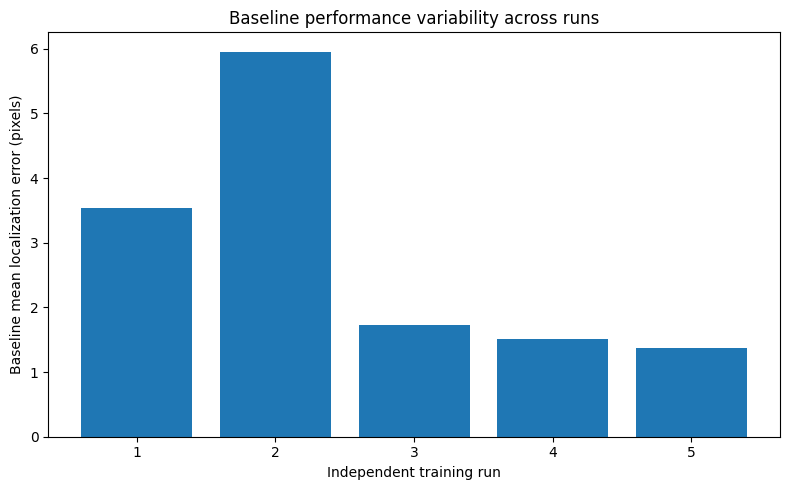

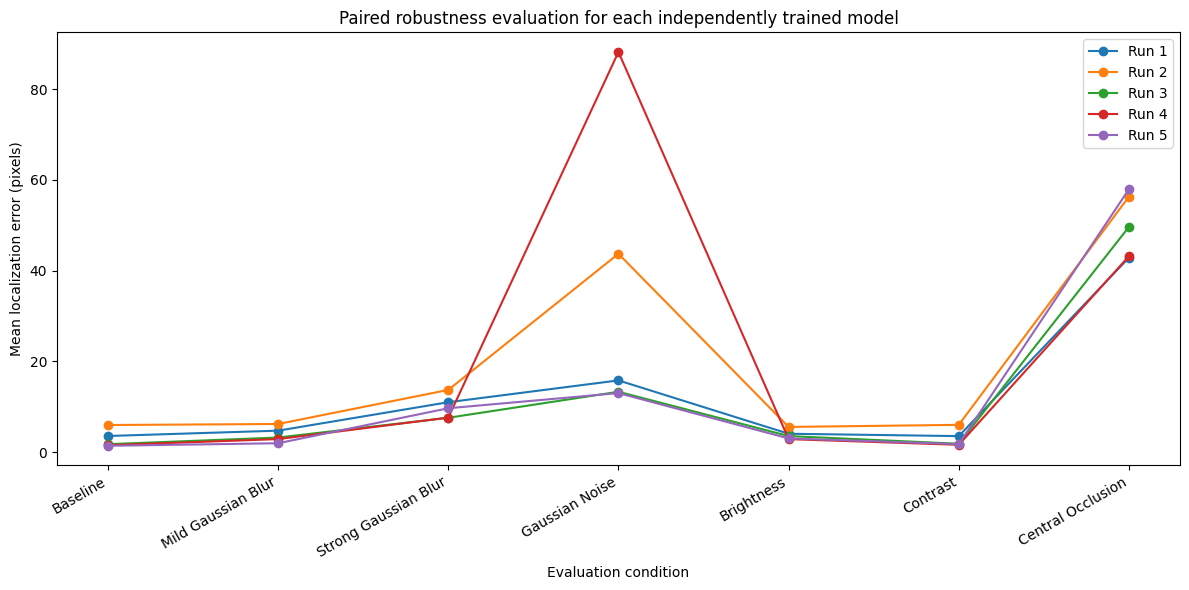

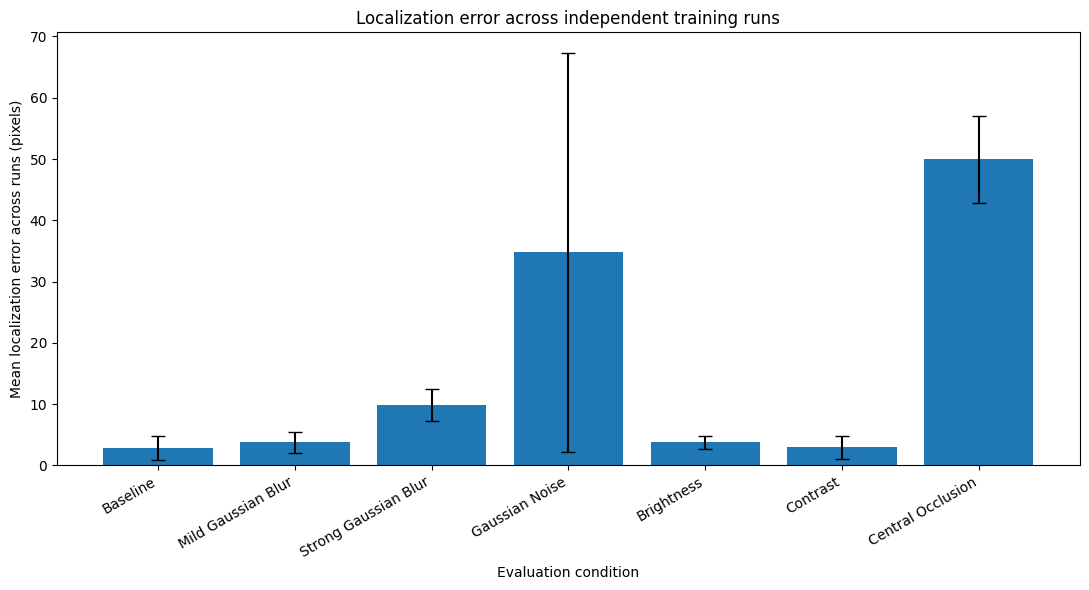

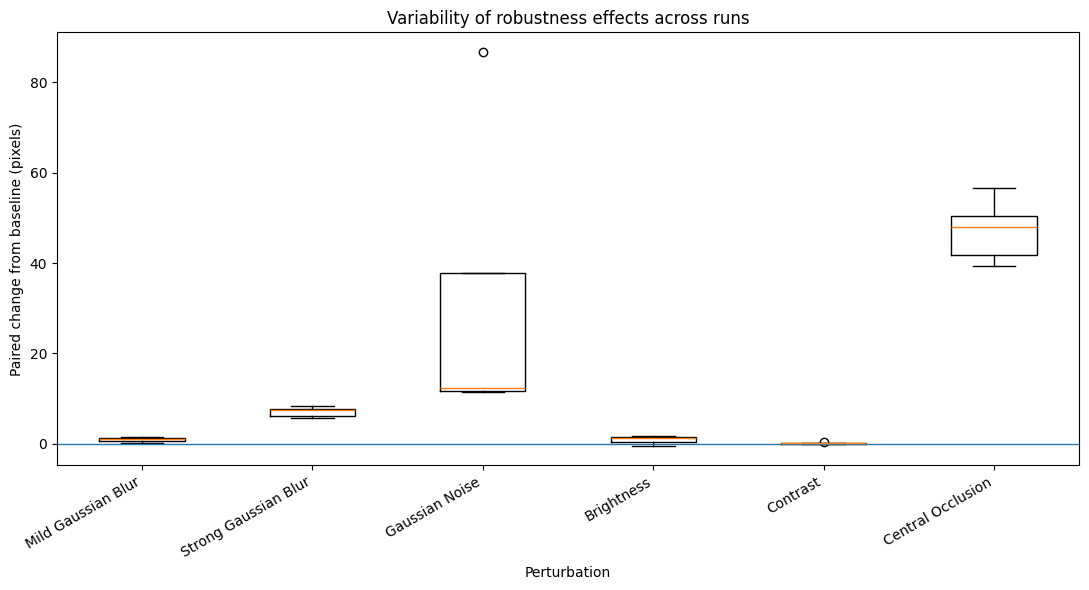

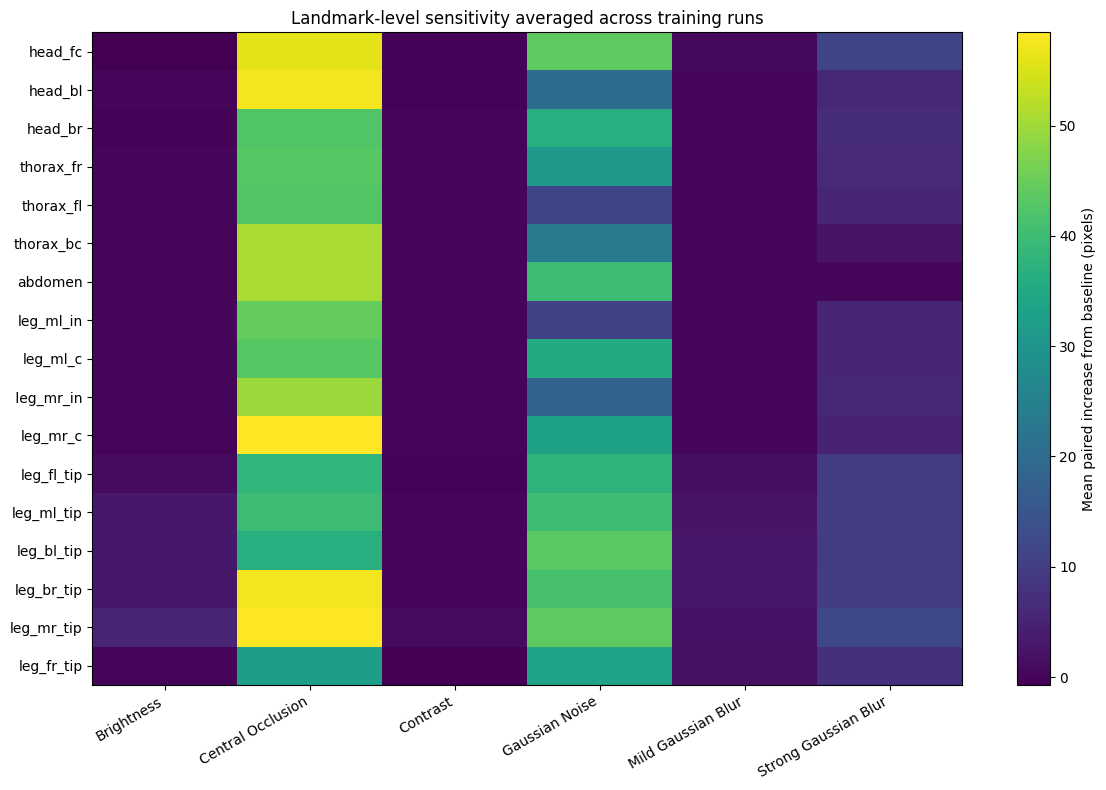

Figures saved to: /content/pose_estimation_multirun_study/figures


In [42]:
FIGURE_DIR = STUDY_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

# Figure 1: Baseline variability across runs.
figure1 = FIGURE_DIR / "figure1_baseline_variability.png"
plt.figure(figsize=(8, 5))
plt.bar(
    baseline_across_runs["Run"].astype(str),
    baseline_across_runs["Mean error (px)"]
)
plt.xlabel("Independent training run")
plt.ylabel("Baseline mean localization error (pixels)")
plt.title("Baseline performance variability across runs")
plt.tight_layout()
plt.savefig(figure1, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Figure 2: Paired lines for all conditions in every run.
figure2 = FIGURE_DIR / "figure2_paired_condition_performance.png"
condition_order = list(CONDITIONS.keys())
plt.figure(figsize=(12, 6))
for _, row in mean_error_wide.iterrows():
    values = [row[name] for name in condition_order]
    plt.plot(
        condition_order,
        values,
        marker="o",
        label=f"Run {int(row['Run'])}"
    )
plt.ylabel("Mean localization error (pixels)")
plt.xlabel("Evaluation condition")
plt.title("Paired robustness evaluation for each independently trained model")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(figure2, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Figure 3: Mean ± SD across runs by condition.
figure3 = FIGURE_DIR / "figure3_mean_sd_by_condition.png"
plt.figure(figsize=(11, 6))
plt.bar(
    summary_across_runs["Condition"],
    summary_across_runs["Mean error across runs (px)"],
    yerr=summary_across_runs["SD across runs (px)"],
    capsize=5
)
plt.ylabel("Mean localization error across runs (pixels)")
plt.xlabel("Evaluation condition")
plt.title("Localization error across independent training runs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(figure3, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Figure 4: Distribution of paired changes versus baseline.
figure4 = FIGURE_DIR / "figure4_paired_changes_boxplot.png"
perturbation_order = [
    name for name in condition_order if name != "Baseline"
]
change_data = [
    paired_changes.loc[
        paired_changes["Condition"] == condition_name,
        "Absolute change (px)"
    ].to_numpy()
    for condition_name in perturbation_order
]
plt.figure(figsize=(11, 6))
plt.boxplot(change_data, tick_labels=perturbation_order)
plt.axhline(0, linewidth=1)
plt.ylabel("Paired change from baseline (pixels)")
plt.xlabel("Perturbation")
plt.title("Variability of robustness effects across runs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(figure4, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Figure 5: Landmark robustness heatmap.
figure5 = FIGURE_DIR / "figure5_landmark_robustness_heatmap.png"
plt.figure(figsize=(12, 8))
heatmap_values = landmark_change_heatmap.to_numpy()
plt.imshow(heatmap_values, aspect="auto")
plt.colorbar(label="Mean paired increase from baseline (pixels)")
plt.xticks(
    np.arange(len(landmark_change_heatmap.columns)),
    landmark_change_heatmap.columns,
    rotation=30,
    ha="right"
)
plt.yticks(
    np.arange(len(landmark_change_heatmap.index)),
    landmark_change_heatmap.index
)
plt.title("Landmark-level sensitivity averaged across training runs")
plt.tight_layout()
plt.savefig(figure5, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print("Figures saved to:", FIGURE_DIR)


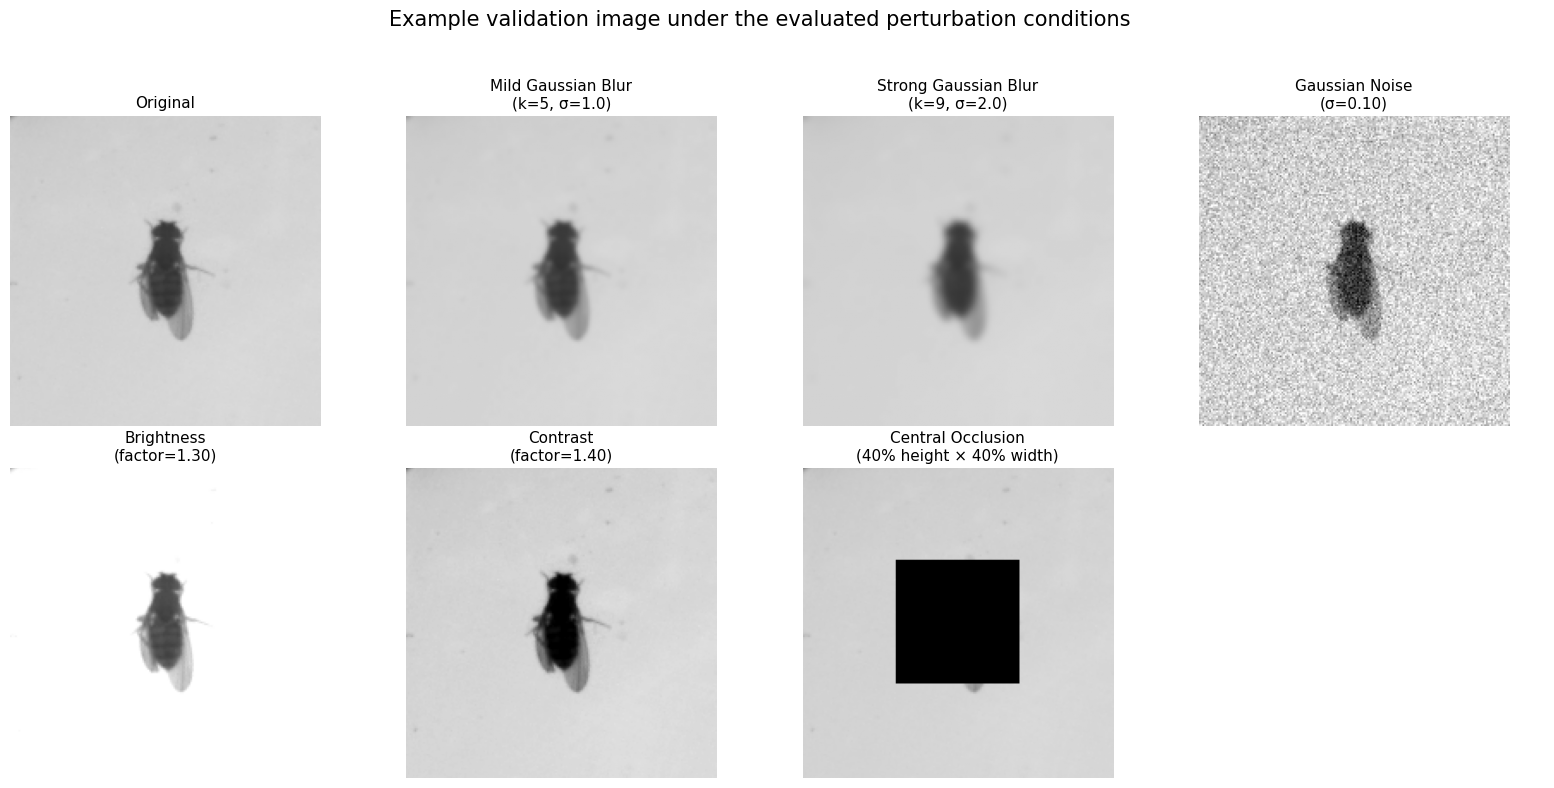

Saved: /content/pose_estimation_multirun_study/figures/figure0a_example_perturbations.png


In [45]:
# ============================================================
# QUALITATIVE FIGURE A:
# Same validation image under every perturbation
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

FIGURE_DIR = STUDY_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Fixed validation example for reproducibility.
# You may change 0 to another valid index if this image is unclear.
QUALITATIVE_SAMPLE_INDEX = 0

sample = val_subset[QUALITATIVE_SAMPLE_INDEX]
original_image = sample["image"].detach().cpu().clone()


def image_for_display(image_tensor):
    """
    Convert a C x H x W PyTorch image into a format accepted by plt.imshow().
    """
    image = image_tensor.detach().cpu().float()

    if image.ndim != 3:
        raise ValueError(
            f"Expected image shape [C, H, W], but received {tuple(image.shape)}"
        )

    if image.shape[0] == 1:
        return image.squeeze(0).numpy()

    return image.permute(1, 2, 0).numpy()


qualitative_conditions = {
    "Original": identity_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
    "Mild Gaussian Blur\n(k=5, σ=1.0)": mild_blur_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
    "Strong Gaussian Blur\n(k=9, σ=2.0)": strong_blur_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
    "Gaussian Noise\n(σ=0.10)": gaussian_noise_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
    "Brightness\n(factor=1.30)": brightness_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
    "Contrast\n(factor=1.40)": contrast_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
    "Central Occlusion\n(40% height × 40% width)": occlusion_transform(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    ),
}

figure_qualitative_perturbations = (
    FIGURE_DIR / "figure0a_example_perturbations.png"
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for axis, (condition_name, perturbed_image) in zip(
    axes,
    qualitative_conditions.items()
):
    displayed_image = image_for_display(perturbed_image)

    if displayed_image.ndim == 2:
        axis.imshow(displayed_image, cmap="gray", vmin=0, vmax=1)
    else:
        axis.imshow(np.clip(displayed_image, 0, 1))

    axis.set_title(condition_name, fontsize=11)
    axis.axis("off")

# Hide the unused eighth panel.
for axis in axes[len(qualitative_conditions):]:
    axis.axis("off")

fig.suptitle(
    "Example validation image under the evaluated perturbation conditions",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    figure_qualitative_perturbations,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("Saved:", figure_qualitative_perturbations)

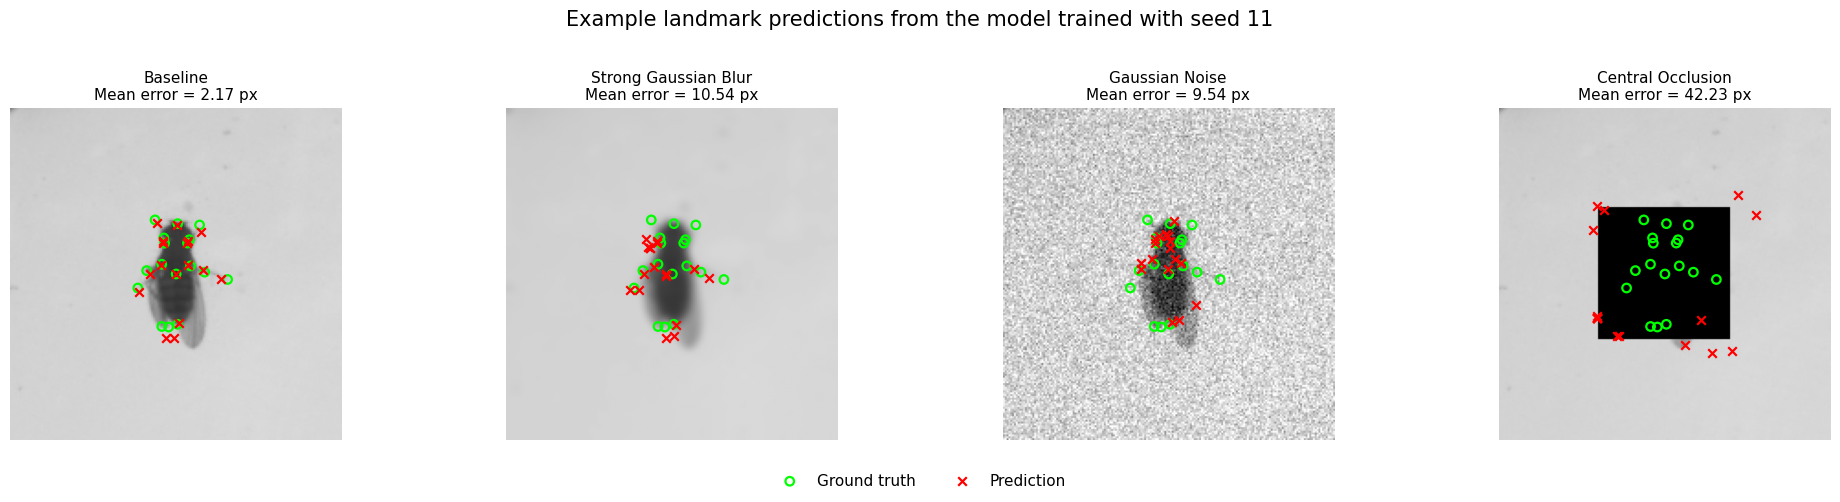

Loaded model: /content/pose_estimation_multirun_study/unet_seed_11.pth
Saved: /content/pose_estimation_multirun_study/figures/figure0b_example_predictions.png


In [46]:
# ============================================================
# QUALITATIVE FIGURE B:
# Ground-truth and predicted landmarks under representative
# perturbation conditions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

FIGURE_DIR = STUDY_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Use one trained model only for this qualitative illustration.
QUALITATIVE_MODEL_SEED = 11
model_path = STUDY_ROOT / f"unet_seed_{QUALITATIVE_MODEL_SEED}.pth"

if not model_path.exists():
    raise FileNotFoundError(
        f"Model weights were not found at:\n{model_path}\n"
        "Confirm that the training cell saved unet_seed_11.pth."
    )

qualitative_model = UNet(
    n_channels=imsize[-1],
    n_landmarks=train_dataset.nlandmarks
).to(device)

state_dict = torch.load(
    model_path,
    map_location=device
)

qualitative_model.load_state_dict(state_dict)
qualitative_model.eval()

sample = val_subset[QUALITATIVE_SAMPLE_INDEX]
original_image = sample["image"].detach().cpu().clone()

ground_truth = sample["landmarks"]

if isinstance(ground_truth, torch.Tensor):
    ground_truth = ground_truth.detach().cpu().numpy()
else:
    ground_truth = np.asarray(ground_truth)

prediction_conditions = {
    "Baseline": identity_transform,
    "Strong Gaussian Blur": strong_blur_transform,
    "Gaussian Noise": gaussian_noise_transform,
    "Central Occlusion": occlusion_transform,
}


def predict_landmarks_for_image(model, image_tensor):
    """
    Run inference for one C x H x W image and return landmark coordinates.
    """
    model.eval()

    model_input = (
        image_tensor
        .unsqueeze(0)
        .to(device=device, dtype=torch.float32)
    )

    with torch.no_grad():
        predicted_logits = model(model_input)
        predicted_heatmaps = torch.sigmoid(predicted_logits)

    predicted_locations = heatmap2landmarks(
        predicted_heatmaps.detach().cpu().numpy()
    )

    return predicted_locations[0]


figure_qualitative_predictions = (
    FIGURE_DIR / "figure0b_example_predictions.png"
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for axis, (condition_name, transform_function) in zip(
    axes,
    prediction_conditions.items()
):
    perturbed_image = transform_function(
        original_image.clone(),
        QUALITATIVE_SAMPLE_INDEX
    )

    predicted_landmarks = predict_landmarks_for_image(
        qualitative_model,
        perturbed_image
    )

    displayed_image = image_for_display(perturbed_image)

    if displayed_image.ndim == 2:
        axis.imshow(displayed_image, cmap="gray", vmin=0, vmax=1)
    else:
        axis.imshow(np.clip(displayed_image, 0, 1))

    # Ground-truth landmarks.
    axis.scatter(
        ground_truth[:, 0],
        ground_truth[:, 1],
        s=38,
        facecolors="none",
        edgecolors="lime",
        linewidths=1.6,
        label="Ground truth"
    )

    # Predicted landmarks.
    axis.scatter(
        predicted_landmarks[:, 0],
        predicted_landmarks[:, 1],
        s=38,
        marker="x",
        c="red",
        linewidths=1.6,
        label="Prediction"
    )

    per_landmark_errors = np.sqrt(
        np.sum(
            (predicted_landmarks - ground_truth) ** 2,
            axis=1
        )
    )
    example_mean_error = float(np.mean(per_landmark_errors))

    axis.set_title(
        f"{condition_name}\nMean error = {example_mean_error:.2f} px",
        fontsize=11
    )
    axis.axis("off")

# Show one common legend for the whole figure.
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=11
)

fig.suptitle(
    f"Example landmark predictions from the model trained with seed "
    f"{QUALITATIVE_MODEL_SEED}",
    fontsize=15
)

plt.tight_layout(rect=[0, 0.09, 1, 0.91])
plt.savefig(
    figure_qualitative_predictions,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("Loaded model:", model_path)
print("Saved:", figure_qualitative_predictions)

# Free GPU memory after generating the illustration.
del qualitative_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 9. Optional paired statistical tests

With only three runs, statistical tests have very low power and should be treated as exploratory. Five or more runs are preferable.

The primary evidence should remain the paired changes, their variability, and the percentage of runs showing increased error.


In [43]:
try:
    from scipy.stats import ttest_rel, wilcoxon
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
    from scipy.stats import ttest_rel, wilcoxon

statistical_rows = []
baseline_vector = mean_error_wide["Baseline"].to_numpy()

for condition_name in perturbation_order:
    condition_vector = mean_error_wide[condition_name].to_numpy()
    differences = condition_vector - baseline_vector

    t_result = ttest_rel(condition_vector, baseline_vector)

    try:
        w_result = wilcoxon(
            condition_vector,
            baseline_vector,
            alternative="greater"
        )
        wilcoxon_stat = float(w_result.statistic)
        wilcoxon_p = float(w_result.pvalue)
    except ValueError:
        wilcoxon_stat = np.nan
        wilcoxon_p = np.nan

    statistical_rows.append({
        "Condition": condition_name,
        "Mean paired change (px)": np.mean(differences),
        "SD paired change (px)": np.std(differences, ddof=1),
        "Paired t-test p-value": float(t_result.pvalue),
        "One-sided Wilcoxon p-value": wilcoxon_p,
        "Runs increased / total": f"{int(np.sum(differences > 0))}/{len(differences)}",
    })

statistical_summary = pd.DataFrame(statistical_rows)
display(statistical_summary.round(4))
statistical_summary.to_csv(
    STUDY_ROOT / "paired_statistical_tests.csv",
    index=False
)


,Condition,Mean paired change (px),SD paired change (px),Paired t-test p-value,One-sided Wilcoxon p-value,Runs increased / total
0,Mild Gaussian Blur,0.9544,0.5368,0.0165,0.0312,5/5
1,Strong Gaussian Blur,7.0724,1.0704,0.0001,0.0312,5/5
2,Gaussian Noise,31.9712,32.5786,0.0932,0.0312,5/5
3,Brightness,0.9653,0.9229,0.0795,0.0625,4/5
4,Contrast,0.1135,0.1534,0.1732,0.0625,4/5
5,Central Occlusion,47.1626,6.9091,0.0001,0.0312,5/5


## 10. Generate the final multi-run robustness report

The report uses results from all runs. It does not copy conclusions from a previous execution.

Its conclusions are generated conservatively from:

- mean and standard deviation across runs;
- paired change relative to each run's own baseline;
- the percentage of runs in which error increased;
- landmark-level averages across runs.

The report does not claim that a perturbation consistently degrades performance unless every completed run shows an increase.


In [44]:
try:
    from docx import Document
    from docx.shared import Inches, Pt
    from docx.enum.text import WD_ALIGN_PARAGRAPH
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "python-docx", "-q"]
    )
    from docx import Document
    from docx.shared import Inches, Pt
    from docx.enum.text import WD_ALIGN_PARAGRAPH


REPORT_DIR = STUDY_ROOT / "final_report"
REPORT_DIR.mkdir(exist_ok=True)

def add_dataframe_table(document, dataframe, decimals=3):
    table = document.add_table(
        rows=1,
        cols=len(dataframe.columns)
    )
    table.style = "Table Grid"

    for col_index, column in enumerate(dataframe.columns):
        table.rows[0].cells[col_index].text = str(column)

    for _, row in dataframe.iterrows():
        cells = table.add_row().cells
        for col_index, column in enumerate(dataframe.columns):
            value = row[column]
            if isinstance(value, (float, np.floating)):
                cells[col_index].text = (
                    "" if pd.isna(value) else f"{float(value):.{decimals}f}"
                )
            else:
                cells[col_index].text = str(value)

    return table


# Build conservative findings.
baseline_mean = baseline_across_runs["Mean error (px)"].mean()
baseline_sd = baseline_across_runs["Mean error (px)"].std(ddof=1)
baseline_pck_mean = baseline_across_runs["PCK@5 (%)"].mean()
baseline_pck_sd = baseline_across_runs["PCK@5 (%)"].std(ddof=1)

key_findings = [
    (
        f"Across {N_RUNS} independently trained models, baseline mean "
        f"localization error was {baseline_mean:.2f} ± {baseline_sd:.2f} pixels, "
        f"and baseline PCK@5 was {baseline_pck_mean:.1f} ± "
        f"{baseline_pck_sd:.1f}%."
    )
]

for _, row in summary_across_runs.iterrows():
    condition_name = row["Condition"]
    if condition_name == "Baseline":
        continue

    mean_change = float(row["Mean paired change vs baseline (px)"])
    sd_change = float(row["SD paired change (px)"])
    consistency = float(row["Runs with increased error (%)"])
    increased_runs = int(round(consistency * N_RUNS / 100))

    if consistency == 100:
        consistency_phrase = "increased error in every run"
    elif consistency >= 75:
        consistency_phrase = "increased error in most runs"
    elif consistency > 50:
        consistency_phrase = "increased error in more than half of the runs"
    elif consistency == 50:
        consistency_phrase = "increased error in half of the runs"
    else:
        consistency_phrase = "did not consistently increase error"

    key_findings.append(
        f"{condition_name} produced a mean paired change of "
        f"{mean_change:+.2f} ± {sd_change:.2f} pixels and "
        f"{consistency_phrase} ({increased_runs}/{N_RUNS})."
    )

# Identify perturbation with largest mean paired degradation.
nonbaseline_summary = summary_across_runs[
    summary_across_runs["Condition"] != "Baseline"
].sort_values(
    "Mean paired change vs baseline (px)",
    ascending=False
)
largest_condition = nonbaseline_summary.iloc[0]

key_findings.append(
    f"The largest average degradation was observed for "
    f"{largest_condition['Condition']} "
    f"({largest_condition['Mean paired change vs baseline (px)']:+.2f} pixels "
    f"relative to baseline)."
)

# Most difficult baseline landmark across runs.
baseline_landmark_summary = landmark_summary[
    landmark_summary["Condition"] == "Baseline"
].sort_values("Mean error across runs (px)", ascending=False)

hardest_landmark = baseline_landmark_summary.iloc[0]
easiest_landmark = baseline_landmark_summary.iloc[-1]

key_findings.append(
    f"Across runs, the highest baseline landmark error was observed for "
    f"{hardest_landmark['Landmark']} "
    f"({hardest_landmark['Mean error across runs (px)']:.2f} px), while "
    f"{easiest_landmark['Landmark']} had the lowest "
    f"({easiest_landmark['Mean error across runs (px)']:.2f} px)."
)

# Report tables.
table1 = run_results[
    [
        "Run", "Seed", "Condition", "Mean error (px)",
        "Median error (px)", "PCK@5 (%)", "PCK@10 (%)"
    ]
].copy()

table2 = summary_across_runs.copy()

table3 = paired_changes[
    [
        "Run", "Seed", "Condition",
        "Baseline mean error (px)",
        "Perturbed mean error (px)",
        "Absolute change (px)",
        "Relative change (%)"
    ]
].copy()

# Top landmark changes averaged across runs.
table4 = (
    landmark_summary[
        landmark_summary["Condition"] != "Baseline"
    ]
    .sort_values(
        ["Condition", "Mean paired change vs baseline (px)"],
        ascending=[True, False]
    )
    .copy()
)

# Create Word report.
docx_path = REPORT_DIR / "multirun_pose_estimation_robustness_report.docx"
document = Document()

title = document.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
title_run = title.add_run(
    "Animal Pose Estimation\nMulti-Run Robustness Study"
)
title_run.bold = True
title_run.font.size = Pt(18)

subtitle = document.add_paragraph()
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER
subtitle.add_run(
    f"{N_RUNS} independent training runs and "
    f"{len(CONDITIONS) - 1} image perturbations"
).italic = True

document.add_heading("Executive Summary", level=1)
for finding in key_findings:
    document.add_paragraph(finding, style="List Bullet")

document.add_heading("1. Research Question", level=1)
document.add_paragraph(
    "How robust is the Neuromatch U-Net animal pose estimation model to "
    "common image perturbations across multiple independent training runs?"
)

document.add_heading("2. Experimental Design", level=1)
document.add_paragraph(
    f"{N_RUNS} independently initialized U-Net models were trained using "
    f"seeds {RUN_SEEDS}. A fixed validation split was used in every run. "
    "Each trained model was evaluated on the same validation examples under "
    "the baseline condition and all perturbation conditions. Changes were "
    "computed relative to the corresponding baseline from the same run."
)
document.add_paragraph(
    "The perturbations were Gaussian Blur, Gaussian Noise, increased "
    "Brightness, increased Contrast, and Central Occlusion. These appearance "
    "transformations preserve landmark coordinates."
)

document.add_heading("3. Performance in Every Run", level=1)
document.add_paragraph(
    "Table 1 reports the main performance metrics for every run and condition."
)
document.add_paragraph("Table 1. Run-level quantitative results.")
add_dataframe_table(document, table1)

document.add_heading("4. Summary Across Runs", level=1)
document.add_paragraph(
    "Table 2 reports the mean and variability across independently trained "
    "models. The paired change compares each condition with the same model's "
    "baseline."
)
document.add_paragraph("Table 2. Summary across independent training runs.")
add_dataframe_table(document, table2)

document.add_picture(str(figure1), width=Inches(6.2))
document.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
document.add_paragraph(
    "Figure 1. Baseline mean localization error for each independent run."
)

document.add_picture(str(figure2), width=Inches(6.5))
document.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
document.add_paragraph(
    "Figure 2. Paired performance of every independently trained model "
    "across evaluation conditions."
)

document.add_picture(str(figure3), width=Inches(6.5))
document.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
document.add_paragraph(
    "Figure 3. Mean localization error and standard deviation across runs."
)

document.add_heading("5. Paired Robustness Effects", level=1)
document.add_paragraph(
    "Table 3 shows the change produced by each perturbation relative to the "
    "baseline of the same training run."
)
document.add_paragraph("Table 3. Paired changes relative to baseline.")
add_dataframe_table(document, table3)

document.add_picture(str(figure4), width=Inches(6.5))
document.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
document.add_paragraph(
    "Figure 4. Distribution of paired changes relative to baseline across runs."
)

document.add_heading("6. Landmark-Level Robustness", level=1)
document.add_paragraph(
    "Table 4 reports landmark-level performance averaged across runs. "
    "Positive paired changes indicate increased localization error relative "
    "to baseline."
)
document.add_paragraph(
    "Table 4. Landmark-level robustness summary across runs."
)
add_dataframe_table(document, table4)

document.add_picture(str(figure5), width=Inches(6.5))
document.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
document.add_paragraph(
    "Figure 5. Mean paired increase in localization error for each landmark "
    "and perturbation."
)

document.add_heading("7. Statistical Analysis", level=1)
document.add_paragraph(
    "The paired tests below are exploratory, particularly when only three "
    "runs are used. Effect magnitude, variability, and consistency across "
    "runs should receive greater emphasis than p-values."
)
document.add_paragraph("Table 5. Exploratory paired statistical tests.")
add_dataframe_table(document, statistical_summary)

document.add_heading("8. Interpretation", level=1)
for finding in key_findings:
    document.add_paragraph(finding)

document.add_paragraph(
    "A perturbation is interpreted as consistently harmful only when it "
    "increases error across all completed independent runs. When effects "
    "vary in direction or magnitude, the report describes that variability "
    "instead of making a general claim."
)

document.add_heading("9. Limitations", level=1)
limitations = [
    f"The study includes {N_RUNS} independent runs; more runs would provide a more precise estimate of variability.",
    f"Every model was trained for {N_EPOCHS} epochs using the original course-scale architecture and training settings.",
    "Only one predefined severity was used for noise, brightness, contrast, and occlusion, while two blur severities were tested.",
    "The validation split was fixed to isolate training variability; results may also vary under different data splits.",
    "The paired statistical tests are exploratory and have limited power with a small number of runs.",
    "The study evaluates robustness to synthetic perturbations and does not establish performance under all real-world imaging conditions.",
]
for item in limitations:
    document.add_paragraph(item, style="List Bullet")

document.add_heading("10. Conclusion", level=1)
fully_consistent = nonbaseline_summary[
    nonbaseline_summary["Runs with increased error (%)"] == 100
]["Condition"].tolist()

if fully_consistent:
    consistent_text = (
        "The following perturbations increased localization error in every "
        "completed run: " + ", ".join(fully_consistent) + "."
    )
else:
    consistent_text = (
        "No evaluated perturbation increased localization error in every "
        "completed run."
    )

document.add_paragraph(
    f"Across {N_RUNS} independently trained models, baseline performance "
    f"showed a mean error of {baseline_mean:.2f} ± {baseline_sd:.2f} pixels. "
    f"{consistent_text} The magnitude of the robustness effects varied across "
    "models and anatomical landmarks. These multi-run results provide a "
    "stronger basis for evaluating robustness than any individual training run."
)

document.save(docx_path)

# Create HTML report.
html_path = REPORT_DIR / "multirun_pose_estimation_robustness_report.html"

def df_html(dataframe):
    return dataframe.round(N_RUNS).to_html(
        index=False,
        border=0,
        classes="results-table"
    )

html_findings = "".join(
    f"<li>{html.escape(finding)}</li>" for finding in key_findings
)
html_limitations = "".join(
    f"<li>{html.escape(item)}</li>" for item in limitations
)

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Multi-Run Pose Estimation Robustness Study</title>
<style>
body {{
  font-family: Arial, sans-serif;
  max-width: 1150px;
  margin: 40px auto;
  padding: 0 24px;
  line-height: 1.55;
  color: #222;
}}
h1, h2 {{ color: #263238; }}
.results-table {{
  border-collapse: collapse;
  width: 100%;
  margin: 18px 0 30px;
  font-size: 12px;
}}
.results-table th, .results-table td {{
  border: 1px solid #bbb;
  padding: 6px;
}}
.results-table th {{ background: #eee; }}
img {{
  max-width: 100%;
  display: block;
  margin: 22px auto 8px;
}}
.caption {{
  text-align: center;
  color: #555;
  margin-bottom: 28px;
}}
</style>
</head>
<body>
<h1>Animal Pose Estimation: Multi-Run Robustness Study</h1>

<h2>Executive Summary</h2>
<ul>{html_findings}</ul>

<h2>Experimental Design</h2>
<p>
{N_RUNS} independently initialized U-Net models were evaluated on a fixed
validation split. Every perturbation was compared with the same model's
baseline.
</p>

<h2>Table 1. Run-level quantitative results</h2>
{df_html(table1)}

<h2>Table 2. Summary across runs</h2>
{df_html(table2)}

<img src="../figures/{figure1.name}">
<p class="caption">Figure 1. Baseline variability across runs.</p>

<img src="../figures/{figure2.name}">
<p class="caption">Figure 2. Paired condition performance.</p>

<img src="../figures/{figure3.name}">
<p class="caption">Figure 3. Mean ± SD across runs.</p>

<h2>Table 3. Paired changes relative to baseline</h2>
{df_html(table3)}

<img src="../figures/{figure4.name}">
<p class="caption">Figure 4. Paired robustness changes across runs.</p>

<h2>Table 4. Landmark-level summary</h2>
{df_html(table4)}

<img src="../figures/{figure5.name}">
<p class="caption">Figure 5. Landmark robustness heatmap.</p>

<h2>Table 5. Exploratory paired tests</h2>
{df_html(statistical_summary)}

<h2>Limitations</h2>
<ul>{html_limitations}</ul>
</body>
</html>
"""
html_path.write_text(html_content, encoding="utf-8")

# Copy all CSVs and figures into one ZIP package.
zip_path = shutil.make_archive(
    "/content/multirun_pose_estimation_robustness_report",
    "zip",
    root_dir=STUDY_ROOT
)

print("Final multi-run report created.")
print("Word:", docx_path)
print("HTML:", html_path)
print("ZIP:", zip_path)

try:
    from google.colab import files
    print("\nTo download the Word report, run:")
    print(f'files.download("{docx_path}")')
    print("\nTo download the complete ZIP package, run:")
    print(f'files.download("{zip_path}")')
except Exception:
    pass


Final multi-run report created.
Word: /content/pose_estimation_multirun_study/final_report/multirun_pose_estimation_robustness_report.docx
HTML: /content/pose_estimation_multirun_study/final_report/multirun_pose_estimation_robustness_report.html
ZIP: /content/multirun_pose_estimation_robustness_report.zip

To download the Word report, run:
files.download("/content/pose_estimation_multirun_study/final_report/multirun_pose_estimation_robustness_report.docx")

To download the complete ZIP package, run:
files.download("/content/multirun_pose_estimation_robustness_report.zip")


## 11. Download the final report in Google Colab

Run one of these lines in a new code cell after report generation:

```python
from google.colab import files
files.download("/content/pose_estimation_multirun_study/final_report/multirun_pose_estimation_robustness_report.docx")
```

or download the complete package:

```python
from google.colab import files
files.download("/content/multirun_pose_estimation_robustness_report.zip")
```


In [47]:
print(STUDY_ROOT)

/content/pose_estimation_multirun_study


In [ ]:
from google.colab import drive
drive.mount('/content/drive')